In [59]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [32]:
df = pd.read_excel("/content/perfect_final_data_for_multilevel_analysis.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,417,132,41,6,5,2,1,21,1,0,...,2,1,2,1,3,2,0,1,1,0
8498,190,11,43,6,3,1,0,11,1,0,...,1,1,1,3,3,1,1,1,1,1
8499,123,123,40,6,2,2,0,21,1,0,...,1,1,2,2,1,2,0,1,1,1
8500,581,64,30,4,7,2,1,21,2,0,...,2,2,1,2,2,2,0,0,1,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

In [34]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364', 'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V013                        8502 non-null   int64  
 1   V024                        8502 non-null   int64  
 2   V025                        8502 non-null   int64  
 3   V106                        8502 non-null   int64  
 4   V404                        8502 non-null   int64  
 5   V714                        8502 non-null   int64  
 6   BMI_fixed                   8502 non-null   float64
 7   Media_acccess               8502 non-null   int64  
 8   husband_education           8502 non-null   int64  
 9   contraceptive_use           8502 non-null   int64  
 10  Number_of_children          8502 non-null   int64  
 11  Living_children             8502 non-null   int64  
 12  Age_of_husband              8502 non-null   int64  
 13  profession_of_husband       8502 

In [36]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [38]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [39]:
# FT4_df.head()  # this would preview the robust scaled data
y = df.BMI  # use bmi1 as the target variable
x = df.drop('BMI', axis=1)  # use the other columns as features

In [40]:
y  # display the target column

,BMI
0,4
1,4
2,4
3,4
4,4
...,...
8497,1
8498,1
8499,1
8500,1


In [41]:
x  # display the feature columns

,V013,V024,V025,V106,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,Respondent_Age_first_birth
0,7,6,2,0,0,0,0,0,0,2,2,2,1,4,2,0,1,1
1,4,6,1,2,0,1,1,2,0,1,1,1,2,1,2,2,1,0
2,5,4,1,2,0,0,1,3,1,2,2,2,4,1,2,2,1,1
3,7,6,1,0,0,0,1,2,0,2,2,2,2,1,2,2,1,0
4,4,7,2,3,0,0,0,1,0,1,1,1,1,2,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,6,5,2,1,0,0,0,0,1,2,1,2,1,3,2,0,1,0
8498,6,3,1,0,0,0,1,0,0,1,1,1,3,3,1,1,1,1
8499,6,2,2,0,0,0,0,0,1,1,1,2,2,1,2,0,1,1
8500,4,7,2,1,1,0,1,1,1,2,2,1,2,2,2,0,0,1


In [42]:
ohe_columns = [
    'Media_acccess', # Column for media access
    'husband_education', # Column for husband's education
    'contraceptive_use', # Column for contraceptive use
    'Number_of_children', # Column for number of children
    'Living_children', # Column for living children
    'Age_of_husband', # Column for age of husband
    'profession_of_husband', # Column for profession of husband
    'Birth_Interval', # Column for birth interval
    'Drinking_water', # Column for drinking water source
    'Wealth_Status', # Column for wealth status
    'Religion_status', # Column for religion status
    'Respondent_Age_first_birth' # Column for respondent's age at first birth
]

x = pd.get_dummies(x, columns=ohe_columns, drop_first=True) # Apply one-hot encoding to specified columns, dropping the first category to avoid multicollinearity
print(x.head()) # Print the first few rows of the DataFrame with the new one-hot encoded columns

   V013  V024  V025  V106  V404  V714  Media_acccess_1  husband_education_1  \
0     7     6     2     0     0     0            False                False   
1     4     6     1     2     0     1             True                False   
2     5     4     1     2     0     0             True                False   
3     7     6     1     0     0     0             True                False   
4     4     7     2     3     0     0            False                 True   

   husband_education_2  husband_education_3  ...  Birth_Interval_5  \
0                False                False  ...             False   
1                 True                False  ...             False   
2                False                 True  ...             False   
3                 True                False  ...             False   
4                False                False  ...             False   

   Birth_Interval_6  Drinking_water_1  Drinking_water_2  Drinking_water_3  \
0             False        

In [43]:
y = LabelEncoder().fit_transform(y)  # change target labels into numbers

In [44]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(5951, 35)

In [62]:
oversample = SMOTE()  # create SMOTE to balance classes
x_train, y_train = oversample.fit_resample(x_train, y_train)  # make class counts more balanced
counter = Counter(y_train)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y_train) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=2, count=3110, percentage=25.000%
class=1, count=3110, percentage=25.000%
class=3, count=3110, percentage=25.000%
class=0, count=3110, percentage=25.000%


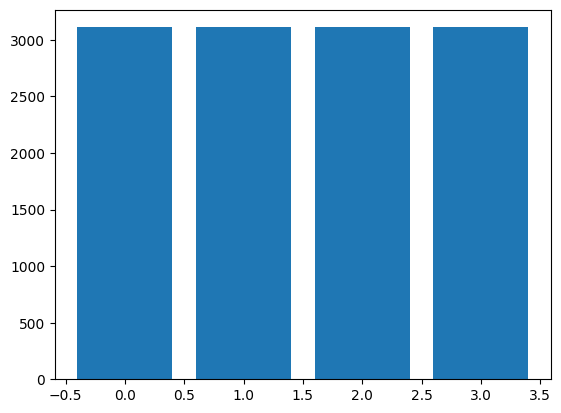

In [63]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [47]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(2551, 35)

In [48]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Training Performance ===
              precision    recall  f1-score   support

           0     0.6097    0.6576    0.6327      3110
           1     0.5214    0.6305    0.5708      3110
           2     0.4587    0.3071    0.3679      3110
           3     0.5893    0.6145    0.6016      3110

    accuracy                         0.5524     12440
   macro avg     0.5448    0.5524    0.5433     12440
weighted avg     0.5448    0.5524    0.5433     12440

[[2045  514  144  407]
 [ 371 1961  568  210]
 [ 462  978  955  715]
 [ 476  308  415 1911]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.1852    0.1875    0.1863       240
           1     0.5604    0.6247    0.5908      1359
           2     0.3959    0.3073    0.3460       755
           3     0.1739    0.1827    0.1782       197

    accuracy                         0.4555      2551
   macro avg     0.3288    0.3256    0.3253      2551
weighted avg     0.4466    0.4555    0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores are [0.5440658  0.54054054 0.54470588 0.52352941 0.55058824 0.53764706
 0.53411765 0.52352941 0.54       0.54       0.55816686 0.53701528
 0.50823529 0.52470588 0.54       0.54823529 0.53294118 0.55294118
 0.55294118 0.51764706 0.52643948 0.54171563 0.53058824 0.54352941
 0.53411765 0.53294118 0.52823529 0.53647059 0.55058824 0.53176471]
Average Cross Validation score :0.5369314531923227


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1420    0.2000    0.1661       240
           1     0.5606    0.4592    0.5049      1359
           2     0.3307    0.3285    0.3296       755
           3     0.1343    0.2386    0.1718       197

    accuracy                         0.3791      2551
   macro avg     0.2919    0.3066    0.2931      2551
weighted avg     0.4203    0.3791    0.3954      2551

[[ 48 112  51  29]
 [196 624 380 159]
 [ 81 311 248 115]
 [ 13  66  71  47]]
Cross Validation Scores are [0.43008226 0.39835488 0.39882353 0.38941176 0.4        0.42235294
 0.38588235 0.37411765 0.36117647 0.40823529 0.39130435 0.37367803
 0.40823529 0.38705882 0.39647059 0.41647059 0.40823529 0.38941176
 0.38235294 0.4        0.42303173 0.41480611 0.38235294 0.40941176
 0.39529412 0.4        0.39764706 0.38117647 0.39529412 0.36941176]
Average Cross Validation score :0.3963360291237529


In [50]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1406    0.1125    0.1250       240
           1     0.5441    0.5673    0.5555      1359
           2     0.3414    0.3377    0.3395       755
           3     0.1487    0.1472    0.1480       197

    accuracy                         0.4241      2551
   macro avg     0.2937    0.2912    0.2920      2551
weighted avg     0.4156    0.4241    0.4196      2551

[[ 27 171  36   6]
 [129 771 383  76]
 [ 31 385 255  84]
 [  5  90  73  29]]
Cross Validation Scores are [0.52408931 0.51116334 0.51529412 0.48352941 0.52588235 0.50588235
 0.49411765 0.51058824 0.50705882 0.51529412 0.51351351 0.52761457
 0.50235294 0.51294118 0.51647059 0.50941176 0.52470588 0.51176471
 0.52588235 0.48352941 0.51351351 0.52408931 0.50941176 0.51882353
 0.50941176 0.49058824 0.50588235 0.50352941 0.51882353 0.50705882]
Average Cross Validation score :0.5107406280961269


In [51]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1458    0.3583    0.2072       240
           1     0.5460    0.3495    0.4262      1359
           2     0.3160    0.2649    0.2882       755
           3     0.1114    0.2589    0.1557       197

    accuracy                         0.3183      2551
   macro avg     0.2798    0.3079    0.2693      2551
weighted avg     0.4067    0.3183    0.3439      2551

[[ 86  87  42  25]
 [356 475 319 209]
 [130 252 200 173]
 [ 18  56  72  51]]
Cross Validation Scores are [0.47943596 0.47121034 0.46352941 0.45058824 0.46352941 0.48941176
 0.47411765 0.44470588 0.48352941 0.46235294 0.46180964 0.47826087
 0.47411765 0.48117647 0.48117647 0.48235294 0.47882353 0.46705882
 0.47764706 0.48470588 0.47708578 0.47943596 0.49176471 0.46823529
 0.47882353 0.43764706 0.46941176 0.45764706 0.48       0.50705882]
Average Cross Validation score :0.47322167691988665


In [52]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1351    0.3417    0.1936       240
           1     0.5495    0.2656    0.3581      1359
           2     0.3322    0.2556    0.2889       755
           3     0.1289    0.4619    0.2016       197

    accuracy                         0.2850      2551
   macro avg     0.2864    0.3312    0.2606      2551
weighted avg     0.4137    0.2850    0.3101      2551

[[ 82  87  35  36]
 [375 361 304 319]
 [132 170 193 260]
 [ 18  39  49  91]]
Cross Validation Scores are [0.47121034 0.41950646 0.12823529 0.41529412 0.43058824 0.44823529
 0.43058824 0.43411765 0.43647059 0.46941176 0.45123384 0.42655699
 0.41411765 0.41647059 0.44588235 0.45411765 0.44117647 0.44352941
 0.11294118 0.42705882 0.42773208 0.43478261 0.40705882 0.44823529
 0.45411765 0.43176471 0.42588235 0.12823529 0.43882353 0.42235294]
Average Cross Validation score :0.40452427363424803


In [53]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1839    0.2292    0.2041       240
           1     0.5507    0.6431    0.5933      1359
           2     0.3960    0.1815    0.2489       755
           3     0.1630    0.2640    0.2016       197

    accuracy                         0.4383      2551
   macro avg     0.3234    0.3294    0.3120      2551
weighted avg     0.4405    0.4383    0.4245      2551

[[ 55 156  16  13]
 [183 874 154 148]
 [ 55 457 137 106]
 [  6 100  39  52]]
Cross Validation Scores are [0.54759107 0.53113984 0.54823529 0.52117647 0.54352941 0.54235294
 0.52588235 0.53294118 0.54       0.53176471 0.55934195 0.53113984
 0.51882353 0.52823529 0.53882353 0.54470588 0.53411765 0.54705882
 0.55529412 0.51529412 0.52878966 0.53936545 0.53058824 0.54823529
 0.53647059 0.53058824 0.52352941 0.54       0.54352941 0.54235294]
Average Cross Validation score :0.5366965738116635


In [54]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1547    0.3583    0.2161       240
           1     0.5592    0.3790    0.4518      1359
           2     0.3440    0.1987    0.2519       755
           3     0.1458    0.4721    0.2228       197

    accuracy                         0.3309      2551
   macro avg     0.3009    0.3520    0.2856      2551
weighted avg     0.4255    0.3309    0.3527      2551

[[ 86 104  24  26]
 [347 515 218 279]
 [112 253 150 240]
 [ 11  49  44  93]]
Cross Validation Scores are [0.52878966 0.54171563 0.54       0.52       0.53176471 0.54117647
 0.53058824 0.53411765 0.52352941 0.55058824 0.54171563 0.51703878
 0.52941176 0.51176471 0.53529412 0.54117647 0.53529412 0.54941176
 0.53764706 0.52       0.52643948 0.52526439 0.52470588 0.52352941
 0.50941176 0.54352941 0.52       0.54117647 0.54823529 0.52588235]
Average Cross Validation score :0.5316399622128521


In [55]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1781    0.2375    0.2036       240
           1     0.5578    0.5077    0.5316      1359
           2     0.3585    0.3205    0.3385       755
           3     0.1630    0.2640    0.2016       197

    accuracy                         0.4081      2551
   macro avg     0.3144    0.3324    0.3188      2551
weighted avg     0.4326    0.4081    0.4181      2551

[[ 57 142  31  10]
 [196 690 333 140]
 [ 62 334 242 117]
 [  5  71  69  52]]
Cross Validation Scores are [0.5346651  0.53936545 0.54352941 0.51058824 0.55529412 0.54352941
 0.52235294 0.53058824 0.52470588 0.53058824 0.54641598 0.53231492
 0.52352941 0.53058824 0.52823529 0.54588235 0.53294118 0.55529412
 0.56117647 0.50352941 0.53701528 0.54054054 0.52235294 0.54235294
 0.53529412 0.53294118 0.52117647 0.54823529 0.54588235 0.55176471]
Average Cross Validation score :0.5357556738324002


In [56]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.1459    0.1125    0.1271       240
           1     0.5465    0.5843    0.5647      1359
           2     0.3333    0.3258    0.3295       755
           3     0.1429    0.1269    0.1344       197

    accuracy                         0.4281      2551
   macro avg     0.2921    0.2874    0.2889      2551
weighted avg     0.4145    0.4281    0.4207      2551

[[ 27 167  39   7]
 [124 794 368  73]
 [ 31 408 246  70]
 [  3  84  85  25]]
Cross Validation Scores are [0.49118684 0.48648649 0.49764706 0.47058824 0.51411765 0.51294118
 0.46823529 0.50588235 0.48       0.47764706 0.47121034 0.49823737
 0.49764706 0.48705882 0.49411765 0.49294118 0.49647059 0.49647059
 0.5        0.46705882 0.48766157 0.48061105 0.47294118 0.49411765
 0.49529412 0.48588235 0.46941176 0.49058824 0.49529412 0.50470588]
Average Cross Validation score :0.48941508260178335


In [57]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

              precision    recall  f1-score   support

           0     0.1447    0.1917    0.1649       240
           1     0.5515    0.5166    0.5334      1359
           2     0.3374    0.3298    0.3336       755
           3     0.1351    0.1523    0.1432       197

    accuracy                         0.4026      2551
   macro avg     0.2922    0.2976    0.2938      2551
weighted avg     0.4177    0.4026    0.4095      2551

[[ 46 142  42  10]
 [187 702 371  99]
 [ 73 350 249  83]
 [ 12  79  76  30]]
Cross Validation Scores are [0.48413631 0.47943596 0.47058824 0.45647059 0.47529412 0.46705882
 0.44823529 0.46       0.45058824 0.45411765 0.46768508 0.46298472
 0.46588235 0.47882353 0.47058824 0.46235294 0.44823529 0.48
 0.46823529 0.48117647 0.47943596 0.48178613 0.47529412 0.46941176
 0.46588235 0.47529412 0.45294118 0.44823529 0.45411765 0.45411765]
Average Cross Validation score :0.4662801778760857


# Model Accuracy Summary

1.  **Logistic Regression** - 53.69%
2.  **Decision Tree** - 39.63%
3.  **Random Forest** - 51.07%
4.  **K-nearest neighbor** - 47.32%
5.  **GaussianNB** - 40.45%
6.  **LinearSVC** - 53.67%
7.  **AdaBoostClassifier** - 53.16%
8.  **GradientBoostingClassifier** - 53.58%
9.  **XGBoost** - 48.94%
10. **BaggingClassifier** - 46.63%